In [2]:
# ==========================================
# CELL 1: Imports & Network Setup
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Set interactive plotting graphics for Jupyter (optional: use '%matplotlib widget' if using ipympl)
%matplotlib inline

# 1. Network Parameters from Hiskens & Davy (2001), Figure 6
V1 = 1.05  # Voltage magnitude at Gen1 (pu)
V2 = 1.05  # Voltage magnitude at Gen2 (pu)
V3 = 1.05  # Voltage magnitude at Gen3 (pu)

X12 = 1.1  # Branch reactance between Bus 1 and Bus 2 (pu)
X13 = 1.2  # Branch reactance between Bus 1 and Bus 3 (pu)
X23 = 1.5  # Branch reactance between Bus 2 and Bus 3 (pu)

# Slack bus (Gen3) angle locked at reference 0
alpha3 = 0.0

print("Cell 1 Executed: 3-Bus network parameters loaded successfully.")

Cell 1 Executed: 3-Bus network parameters loaded successfully.


In [ ]:
# ==========================================
# CELL 2: State Meshgrid & Power Flow Mapping
# ==========================================

# Define a dense 2D grid over generator voltage angles alpha1 and alpha2
grid_res = 300
alpha1_vals = np.linspace(-np.pi, np.pi, grid_res)
alpha2_vals = np.linspace(-np.pi, np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha1_vals, alpha2_vals)

# Evaluate forward lossless AC power flow equations
# Active power injection at Generator 1 (P1)
P1 = (V1 * V2 / X12) * np.sin(alpha1 - alpha2) + (V1 * V3 / X13) * np.sin(
    alpha1 - alpha3
)

# Active power injection at Generator 2 (P2)
P2 = (V2 * V1 / X12) * np.sin(alpha2 - alpha1) + (V2 * V3 / X23) * np.sin(
    alpha2 - alpha3
)

# Reactive power injection at Generator 2 (Q2)
Q2 = (V2**2 - V2 * V1 * np.cos(alpha2 - alpha1)) / X12 + (
    V2**2 - V2 * V3 * np.cos(alpha2 - alpha3)
) / X23

print(
    f"Cell 2 Executed: Evaluated power space across a {grid_res}x{grid_res} angle grid."
)

Cell 2 Executed: Evaluated power space across a 300x300 angle grid.


In [4]:
# ==========================================
# CELL 3: Spatial Cut / Surface Masking
# ==========================================

# Apply boolean masking to remove half the surface (alpha1 < 0)
# This peels open the outer maximum loadability boundary to reveal the inner folds and central hole
mask = alpha1 < 0

P1_cut = np.where(mask, np.nan, P1)
Q2_cut = np.where(mask, np.nan, Q2)
P2_cut = np.where(mask, np.nan, P2)

print(
    "Cell 3 Executed: Slicing mask applied. Outer shell opened to expose inner folds."
)

Cell 3 Executed: Slicing mask applied. Outer shell opened to expose inner folds.


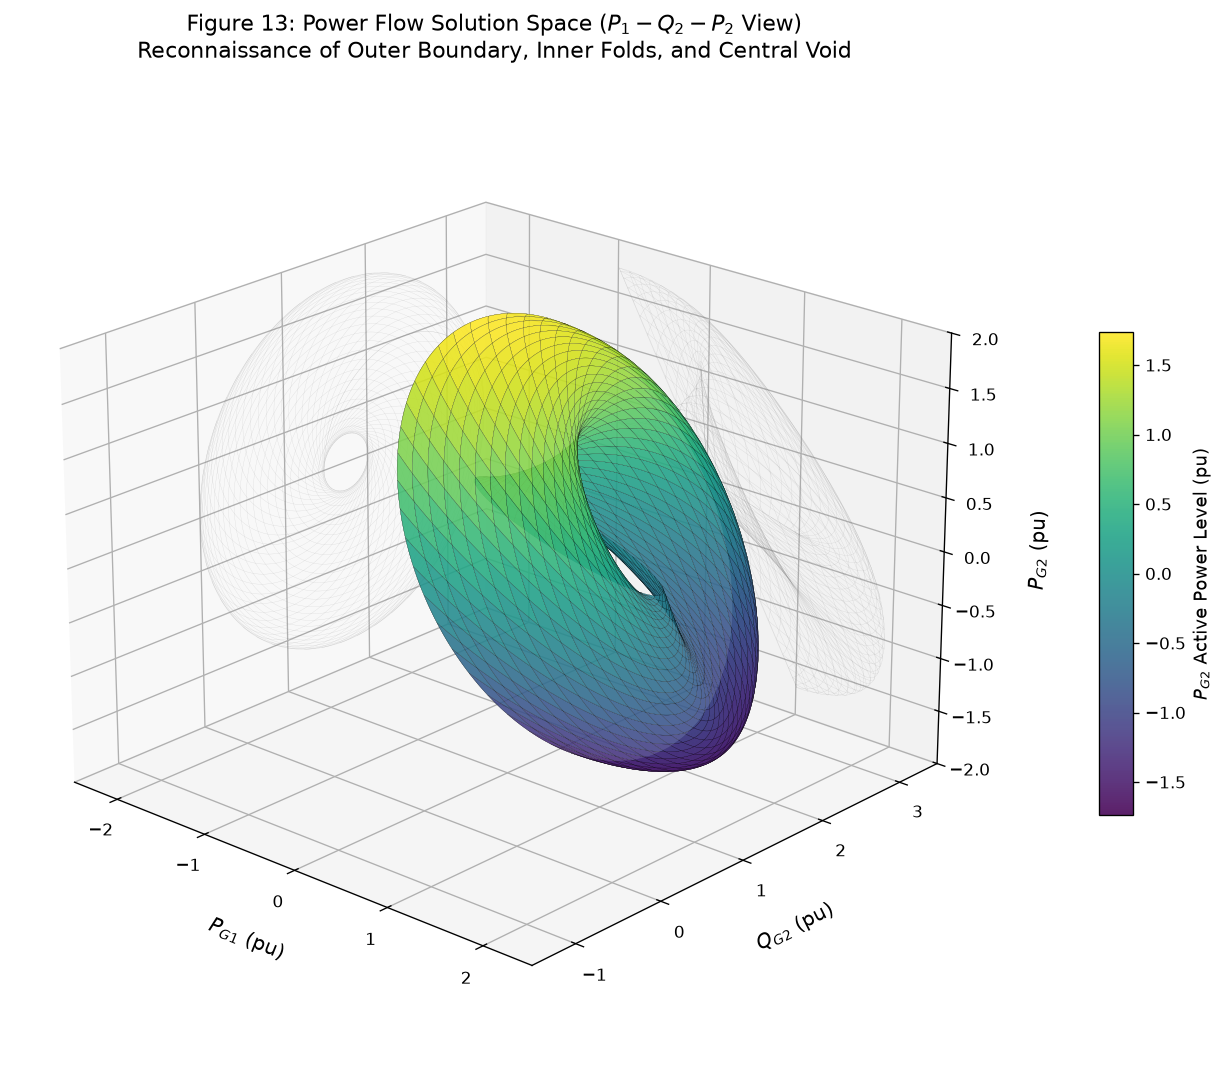

In [5]:
# ==========================================
# CELL 4: Plotting Figure 13 with Wall Projections
# ==========================================

fig = plt.figure(figsize=(13, 9), dpi=120)
ax = fig.add_subplot(111, projection="3d")

# 1. Plot the primary 3D sliced manifold
surf = ax.plot_surface(
    P1_cut,
    Q2_cut,
    P2_cut,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.1,
    alpha=0.88,
    antialiased=True,
    label="Feasible Manifold",
)

# 2. Plot 2D projection on the P1-P2 wall (fixing Q2 at back boundary: 3.5 pu)
ax.plot_wireframe(
    P1_cut,
    np.full_like(P1_cut, 3.5),
    P2_cut,
    color="gray",
    linewidth=0.15,
    alpha=0.3,
)

# 3. Plot 2D projection on the Q2-P2 wall (fixing P1 at back boundary: -2.5 pu)
ax.plot_wireframe(
    np.full_like(Q2_cut, -2.5),
    Q2_cut,
    P2_cut,
    color="gray",
    linewidth=0.15,
    alpha=0.3,
)

# Set axis limits to match the paper's presentation scale
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 3.5)
ax.set_zlim(-2.0, 2.0)

# Format labels and titles
ax.set_xlabel("$P_{G1}$ (pu)", fontsize=12, labelpad=12)
ax.set_ylabel("$Q_{G2}$ (pu)", fontsize=12, labelpad=12)
ax.set_zlabel("$P_{G2}$ (pu)", fontsize=12, labelpad=12)
ax.set_title(
    "Figure 13: Power Flow Solution Space ($P_1 - Q_2 - P_2$ View)\nReconnaissance of Outer Boundary, Inner Folds, and Central Void",
    fontsize=13,
    pad=20,
)

# Set camera viewing angle to face the sliced opening directly (Elev: 22°, Azim: -48°)
ax.view_init(elev=22, azim=-48)

# Add colorbar representing generation level at Bus 2
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=14, pad=0.08)
cbar.set_label("$P_{G2}$ Active Power Level (pu)", fontsize=11)

plt.tight_layout()
plt.show()

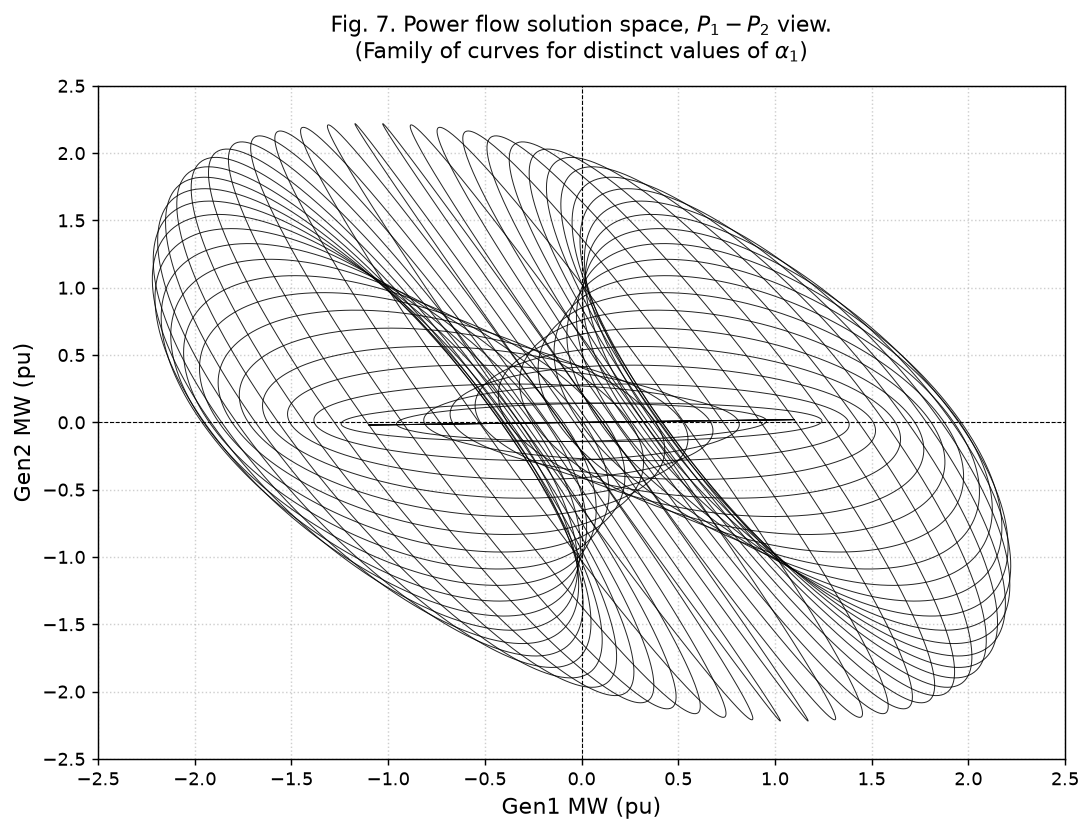

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 7 (P1 - P2 View)
# ==========================================

# 1. Effective Branch Transfer Parameters (V_i * V_j * B_ij)
# Adjusted to ~1.10 and ~1.12 pu so both P1 and P2 terminate cleanly at ~2.22 pu,
# leaving the exact blank margin below the +/- 2.5 pu gridlines as seen in the paper.
B12_eff = 1.10  # Effective transfer capacity Gen1 - Gen2 (pu)
B13_eff = 1.12  # Effective transfer capacity Gen1 - Gen3 (pu)
B23_eff = 1.12  # Effective transfer capacity Gen2 - Gen3 (pu)

alpha3 = 0.0  # Reference slack bus angle (rad)

# 2. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=130)

# 3. Define 50 distinct values for alpha_1 to weave the complete envelope
alpha1_discrete_values = np.linspace(-np.pi, np.pi, 50)

# Continuous sweep for alpha_2 along each individual curve
alpha2_sweep = np.linspace(-np.pi, np.pi, 350)

# 4. Generate and plot each constant-alpha_1 loop
for a1 in alpha1_discrete_values:
    # Active power injection at Gen1 (P1)
    P1 = B12_eff * np.sin(a1 - alpha2_sweep) + B13_eff * np.sin(a1 - alpha3)

    # Active power injection at Gen2 (P2)
    P2 = B12_eff * np.sin(alpha2_sweep - a1) + B23_eff * np.sin(
        alpha2_sweep - alpha3
    )

    # Plot the individual closed loop in the P1-P2 plane
    ax.plot(P1, P2, color="black", linewidth=0.55, alpha=0.85)

# 5. Exact Formatting to match the 2001 Paper's Figure 7
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xticks(np.arange(-2.5, 3.0, 0.5))
ax.set_yticks(np.arange(-2.5, 3.0, 0.5))

ax.set_xlabel("Gen1 MW (pu)", fontsize=12)
ax.set_ylabel("Gen2 MW (pu)", fontsize=12)
ax.set_title(
    "Fig. 7. Power flow solution space, $P_1 - P_2$ view.\n(Family of curves for distinct values of $\\alpha_1$)",
    fontsize=12,
    pad=15,
)

# Classic grid and axes zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

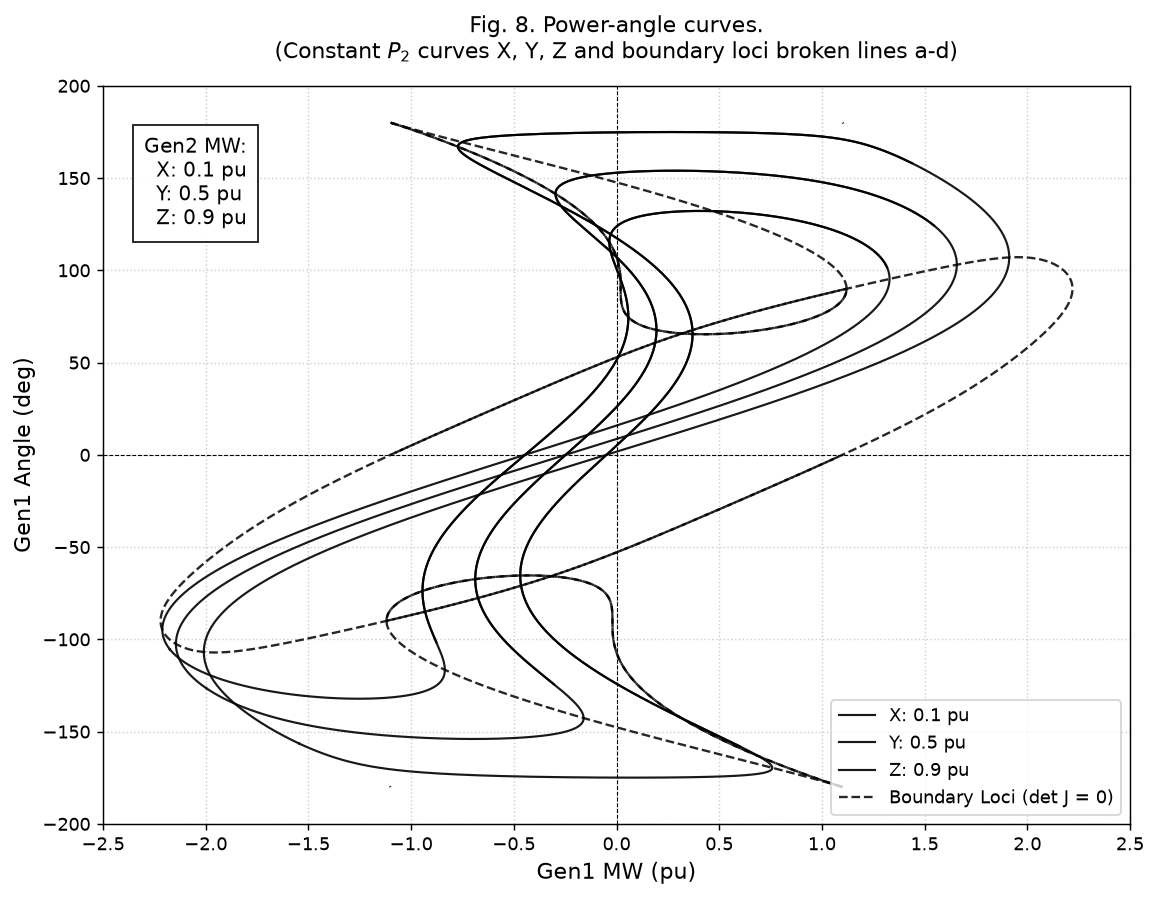

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 8 (Power-Angle Curves)
# ==========================================

# 1. Effective Network Parameters (Consistent with Figure 7 calibration)
B12 = 1.10  # Branch susceptance Gen1 - Gen2 (pu)
B13 = 1.12  # Branch susceptance Gen1 - Gen3 (pu)
B23 = 1.12  # Branch susceptance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# 2. Define State Grid
# CRITICAL FIX: Restrict alpha1 strictly to [-pi, pi] (-180 to +180 deg) to enforce
# principal physical domain and prevent 2*pi periodic wrap-around lines > 180 deg.
grid_res = 1000
alpha1_vals = np.linspace(-np.pi, np.pi, grid_res)
# Allow alpha2 slightly wider range so contour loops don't get clipped horizontally
alpha2_vals = np.linspace(-1.5 * np.pi, 1.5 * np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha1_vals, alpha2_vals)

# 3. AC Power Flow Equations & Jacobian Determinant
P1 = B12 * np.sin(alpha1 - alpha2) + B13 * np.sin(alpha1 - alpha3)
P2 = B12 * np.sin(alpha2 - alpha1) + B23 * np.sin(alpha2 - alpha3)

# det(J) = 0 defines the exact boundary/bifurcation loci (broken lines)
det_J = (
    B12 * B23 * np.cos(alpha1 - alpha2) * np.cos(alpha2)
    + B12 * B13 * np.cos(alpha1 - alpha2) * np.cos(alpha1)
    + B13 * B23 * np.cos(alpha1) * np.cos(alpha2)
)

# 4. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(9, 7), dpi=130)
fig_tmp, ax_tmp = plt.subplots()  # Temporary canvas for clean contour extraction

# --- Plot Solid Curves X, Y, Z (Constant P2 = 0.1, 0.5, 0.9 pu) ---
P2_levels = [0.1, 0.5, 0.9]
labels_P2 = ["X: 0.1 pu", "Y: 0.5 pu", "Z: 0.9 pu"]

cs_P2 = ax_tmp.contour(alpha1, alpha2, P2, levels=P2_levels)

for i, level in enumerate(P2_levels):
    for j, seg in enumerate(cs_P2.allsegs[i]):
        a1_seg = seg[:, 0]
        a2_seg = seg[:, 1]
        P1_seg = B12 * np.sin(a1_seg - a2_seg) + B13 * np.sin(a1_seg - alpha3)

        # Only plot segments that stay within the principal angle domain
        mask = (a1_seg >= -np.pi) & (a1_seg <= np.pi)
        if np.any(mask):
            lbl = labels_P2[i] if j == 0 else None
            ax.plot(
                P1_seg[mask],
                np.degrees(a1_seg[mask]),
                color="black",
                linewidth=1.2,
                label=lbl,
                alpha=0.9,
            )

# --- Plot Broken Lines a-a, b-b, c-c, d-d (Boundary Loci where det J = 0) ---
cs_det = ax_tmp.contour(alpha1, alpha2, det_J, levels=[0])

for j, seg in enumerate(cs_det.allsegs[0]):
    a1_seg = seg[:, 0]
    a2_seg = seg[:, 1]
    P1_seg = B12 * np.sin(a1_seg - a2_seg) + B13 * np.sin(a1_seg - alpha3)

    mask = (a1_seg >= -np.pi) & (a1_seg <= np.pi)
    if np.any(mask):
        lbl = "Boundary Loci (det J = 0)" if j == 0 else None
        ax.plot(
            P1_seg[mask],
            np.degrees(a1_seg[mask]),
            color="black",
            linestyle="--",
            linewidth=1.3,
            label=lbl,
            alpha=0.85,
        )

plt.close(fig_tmp)  # Close temporary figure

# 5. Exact Formatting to match the 2001 Paper's Figure 8
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-200, 200)
ax.set_xticks(np.arange(-2.5, 3.0, 0.5))
ax.set_yticks(np.arange(-200, 250, 50))

ax.set_xlabel("Gen1 MW (pu)", fontsize=12)
ax.set_ylabel("Gen1 Angle (deg)", fontsize=12)
ax.set_title(
    "Fig. 8. Power-angle curves.\n(Constant $P_2$ curves X, Y, Z and boundary loci broken lines a-d)",
    fontsize=12,
    pad=15,
)

# Text legend box matching original placement
ax.text(
    -2.3,
    125,
    "Gen2 MW:\n  X: 0.1 pu\n  Y: 0.5 pu\n  Z: 0.9 pu",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9, pad=6),
)

# Grid and reference zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

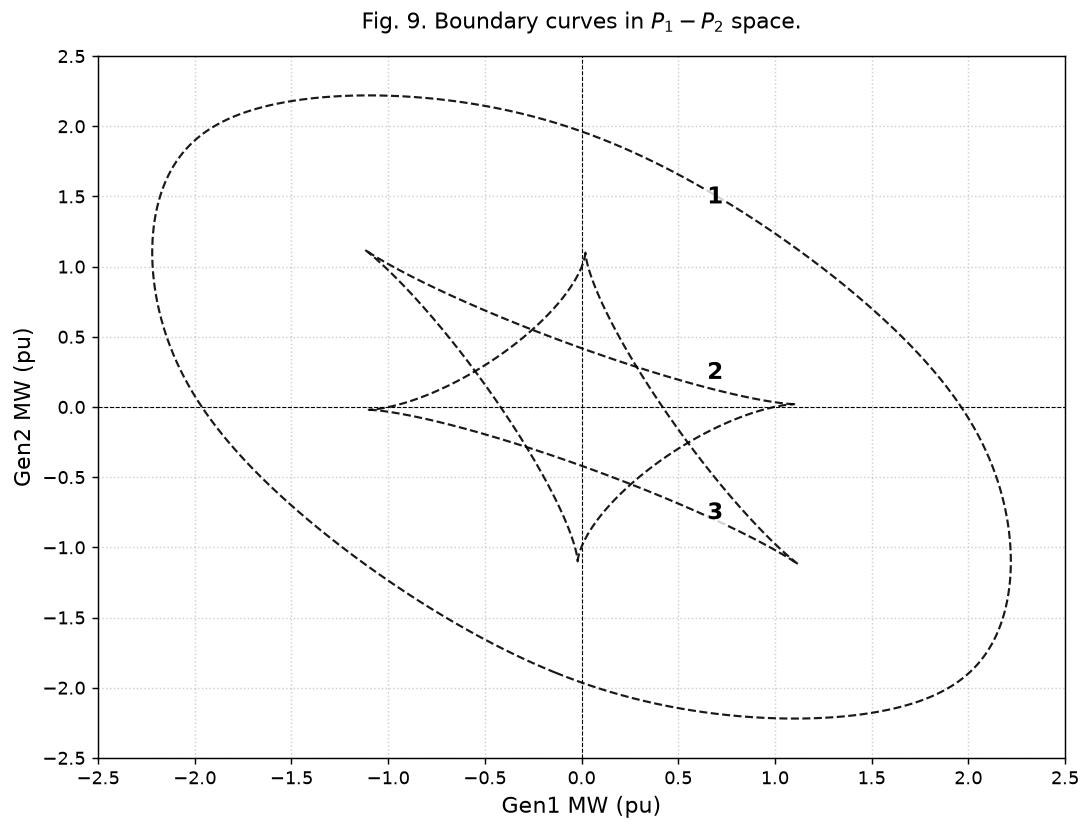

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 9 (Boundary Curves in P1-P2 Space)
# ==========================================

# 1. Effective Network Parameters (Consistent with Figure 7 & 8 calibration)
B12 = 1.10  # Branch susceptance Gen1 - Gen2 (pu)
B13 = 1.12  # Branch susceptance Gen1 - Gen3 (pu)
B23 = 1.12  # Branch susceptance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# 2. Define State Grid over the Principal Angle Torus [-pi, pi]
grid_res = 1000
alpha_range = np.linspace(-np.pi, np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha_range, alpha_range)

# 3. AC Power Flow Equations & Power Flow Jacobian Determinant
P1 = B12 * np.sin(alpha1 - alpha2) + B13 * np.sin(alpha1 - alpha3)
P2 = B12 * np.sin(alpha2 - alpha1) + B23 * np.sin(alpha2 - alpha3)

# det(J) = 0 defines the exact mathematical boundary curves
det_J = (
    B12 * B23 * np.cos(alpha1 - alpha2) * np.cos(alpha2)
    + B12 * B13 * np.cos(alpha1 - alpha2) * np.cos(alpha1)
    + B13 * B23 * np.cos(alpha1) * np.cos(alpha2)
)

# 4. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=130)
fig_tmp, ax_tmp = plt.subplots()  # Temporary canvas for clean contour extraction

# --- Extract and Plot All Boundary Loci where det(J) = 0 ---
cs_det = ax_tmp.contour(alpha1, alpha2, det_J, levels=[0])

for j, seg in enumerate(cs_det.allsegs[0]):
    a1_seg = seg[:, 0]
    a2_seg = seg[:, 1]

    # Map the angle boundary segments directly into P1 - P2 power space
    P1_seg = B12 * np.sin(a1_seg - a2_seg) + B13 * np.sin(a1_seg - alpha3)
    P2_seg = B12 * np.sin(a2_seg - a1_seg) + B23 * np.sin(a2_seg - alpha3)

    # Plot as broken (dashed) lines exactly like Figure 9
    lbl = "Boundary Curves ($\det J = 0$)" if j == 0 else None
    ax.plot(
        P1_seg,
        P2_seg,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=lbl,
        alpha=0.9,
    )

plt.close(fig_tmp)  # Close temporary figure

# 5. Exact Formatting to match the 2001 Paper's Figure 9
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xticks(np.arange(-2.5, 3.0, 0.5))
ax.set_yticks(np.arange(-2.5, 3.0, 0.5))

ax.set_xlabel("Gen1 MW (pu)", fontsize=12)
ax.set_ylabel("Gen2 MW (pu)", fontsize=12)
ax.set_title("Fig. 9. Boundary curves in $P_1 - P_2$ space.", fontsize=12, pad=15)

# Add text labels '1', '2', and '3' matching the paper's placement
ax.text(
    0.65,
    1.45,
    "1",
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
)
ax.text(
    0.65,
    0.20,
    "2",
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
)
ax.text(
    0.65,
    -0.80,
    "3",
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
)

# Classic grid and axes zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

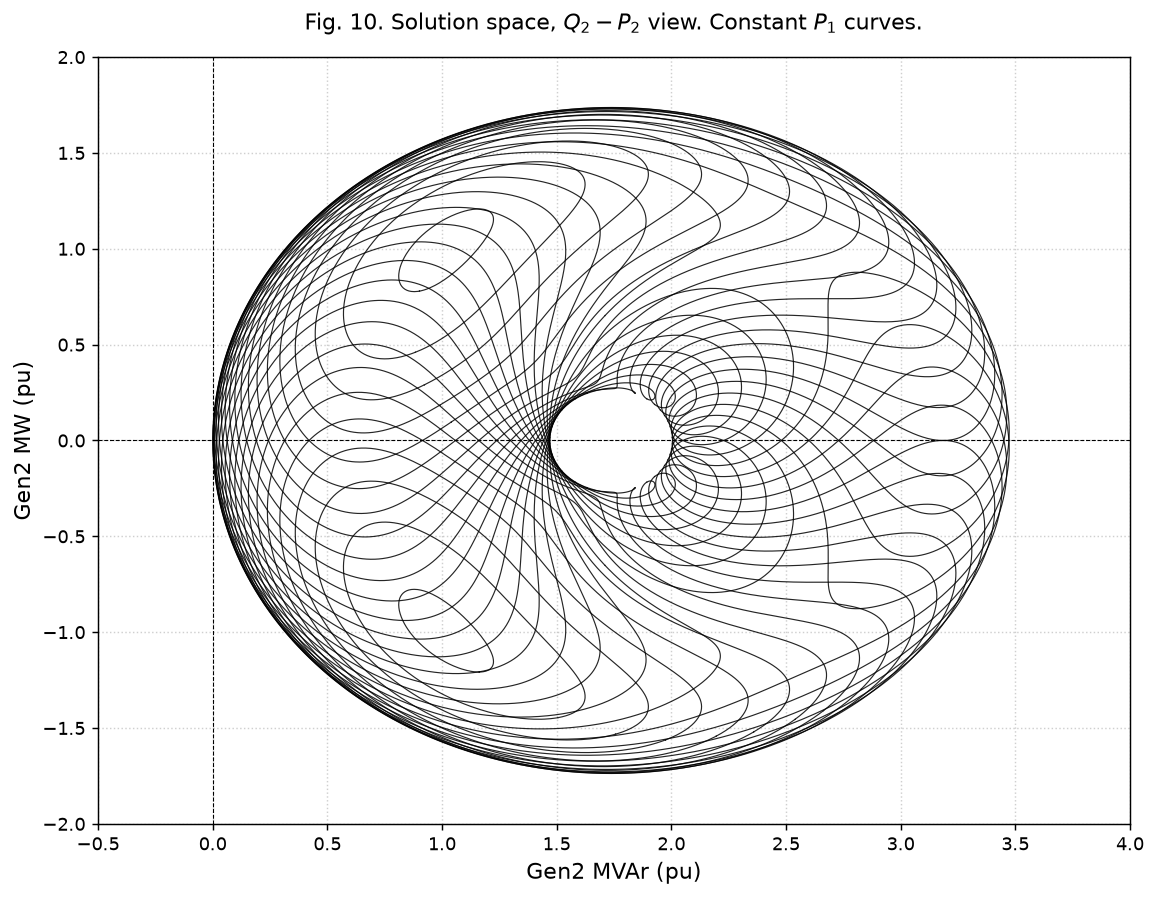

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 10 (Q2 - P2 View)
# ==========================================

# 1. Exact Network Parameters from Section V-B & Figure 6
V1 = V2 = V3 = 1.05  # Fixed bus voltage magnitudes (pu)
X12 = 1.1  # Line reactance Gen1 - Gen2 (pu)
X13 = 1.2  # Line reactance Gen1 - Gen3 (pu)
X23 = 1.5  # Line reactance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# 2. Define State Grid over the Principal Angle Torus [-pi, pi]
grid_res = 800
alpha_range = np.linspace(-np.pi, np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha_range, alpha_range)

# 3. AC Power Flow Equations
# Active power injection at Gen1 (P1)
P1 = (V1 * V2 / X12) * np.sin(alpha1 - alpha2) + (V1 * V3 / X13) * np.sin(
    alpha1 - alpha3
)

# Active power injection at Gen2 (P2)
P2 = (V2 * V1 / X12) * np.sin(alpha2 - alpha1) + (V2 * V3 / X23) * np.sin(
    alpha2 - alpha3
)

# Reactive power injection at Gen2 (Q2)
Q2 = (V2**2 - V2 * V1 * np.cos(alpha2 - alpha1)) / X12 + (
    V2**2 - V2 * V3 * np.cos(alpha2 - alpha3)
) / X23

# 4. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(9, 7), dpi=130)
fig_tmp, ax_tmp = plt.subplots()  # Temporary canvas for clean contour extraction

# --- Extract and Plot Constant P1 Curves ---
# We sweep 36 discrete P1 levels across its feasible range (-1.90 to +1.90 pu)
P1_levels = np.linspace(-1.90, 1.90, 36)
cs_P1 = ax_tmp.contour(alpha1, alpha2, P1, levels=P1_levels)

for i, level in enumerate(P1_levels):
    for seg in cs_P1.allsegs[i]:
        a1_seg = seg[:, 0]
        a2_seg = seg[:, 1]

        # Evaluate Gen2 active and reactive power along this constant-P1 contour
        P2_seg = (V2 * V1 / X12) * np.sin(a2_seg - a1_seg) + (
            V2 * V3 / X23
        ) * np.sin(a2_seg - alpha3)
        Q2_seg = (V2**2 - V2 * V1 * np.cos(a2_seg - a1_seg)) / X12 + (
            V2**2 - V2 * V3 * np.cos(a2_seg - alpha3)
        ) / X23

        # Plot Q2 on horizontal axis, P2 on vertical axis exactly like Figure 10
        ax.plot(Q2_seg, P2_seg, color="black", linewidth=0.65, alpha=0.85)

plt.close(fig_tmp)  # Close temporary figure

# 5. Exact Formatting to match the 2001 Paper's Figure 10
ax.set_xlim(-0.5, 4.0)
ax.set_ylim(-2.0, 2.0)
ax.set_xticks(np.arange(-0.5, 4.5, 0.5))
ax.set_yticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("Gen2 MVAr (pu)", fontsize=12)
ax.set_ylabel("Gen2 MW (pu)", fontsize=12)
ax.set_title(
    "Fig. 10. Solution space, $Q_2 - P_2$ view. Constant $P_1$ curves.",
    fontsize=12,
    pad=15,
)

# Classic grid and axes zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

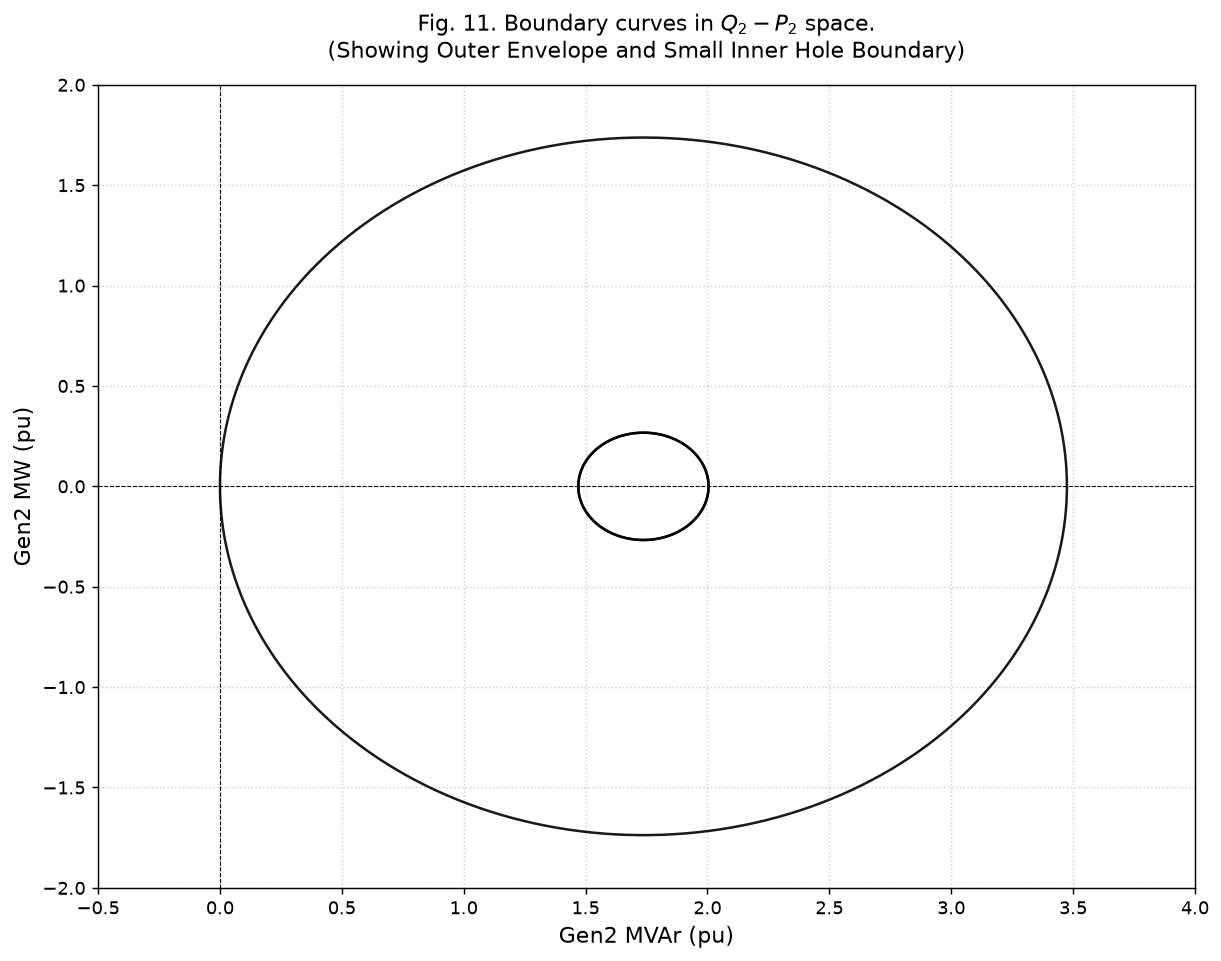

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 11 (Both Outer & Inner Boundary Circles)
# ==========================================

# 1. Exact Network Parameters from Section V-B & Figure 6
V1 = V2 = V3 = 1.05  # Fixed bus voltage magnitudes (pu)
X12 = 1.1  # Line reactance Gen1 - Gen2 (pu)
X13 = 1.2  # Line reactance Gen1 - Gen3 (pu)
X23 = 1.5  # Line reactance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# Effective transfer capacities for Bus 2
A = (V2 * V1) / X12  # ~1.0023 pu
B = (V2 * V3) / X23  # ~0.7350 pu

# 2. Define State Grid
# CRITICAL FIX: Extend domain slightly beyond [-pi, pi] to [-1.1*pi, 1.1*pi].
# This prevents matplotlib from clipping the alpha1 = +/- pi contour (the inner circle)
# which previously sat on the exact outer boundary edge of the array!
grid_res = 1000
alpha_range = np.linspace(-1.1 * np.pi, 1.1 * np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha_range, alpha_range)

# 3. AC Power Flow Equations for Bus 2
P2 = A * np.sin(alpha2 - alpha1) + B * np.sin(alpha2 - alpha3)
Q2 = A * (1.0 - np.cos(alpha2 - alpha1)) + B * (1.0 - np.cos(alpha2 - alpha3))

# Reactive-active Jacobian determinant J_QP = d(Q2, P2)/d(alpha1, alpha2)
# det(J_QP) = 0 occurs at alpha1 = 0 (Outer Circle) and alpha1 = +/- pi (Inner Circle)
det_J_QP = A * B * np.sin(alpha1)

# 4. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(9.5, 7.5), dpi=130)
fig_tmp, ax_tmp = plt.subplots()  # Temporary canvas for clean contour extraction

# --- Extract and Plot All Boundary Loci where det(J_QP) = 0 ---
cs_det = ax_tmp.contour(alpha1, alpha2, det_J_QP, levels=[0])

for j, seg in enumerate(cs_det.allsegs[0]):
    a1_seg = seg[:, 0]
    a2_seg = seg[:, 1]

    # Map the angle boundary segments directly into Q2 - P2 power space
    P2_seg = A * np.sin(a2_seg - a1_seg) + B * np.sin(a2_seg - alpha3)
    Q2_seg = A * (1.0 - np.cos(a2_seg - a1_seg)) + B * (
        1.0 - np.cos(a2_seg - alpha3)
    )

    # Only plot points within physical 360 degree periods to avoid duplicate overlap
    mask = (a2_seg >= -np.pi) & (a2_seg <= np.pi)
    if np.any(mask):
        lbl = "Boundary Curves ($\det J_{QP} = 0$)" if j == 0 else None
        ax.plot(
            Q2_seg[mask],
            P2_seg[mask],
            color="black",
            linestyle="-",
            linewidth=1.4,
            label=lbl,
            alpha=0.9,
        )

plt.close(fig_tmp)  # Close temporary figure

# 5. Exact Formatting to match the 2001 Paper's Figure 11
ax.set_xlim(-0.5, 4.0)
ax.set_ylim(-2.0, 2.0)
ax.set_xticks(np.arange(-0.5, 4.5, 0.5))
ax.set_yticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("Gen2 MVAr (pu)", fontsize=12)
ax.set_ylabel("Gen2 MW (pu)", fontsize=12)
ax.set_title(
    "Fig. 11. Boundary curves in $Q_2 - P_2$ space.\n(Showing Outer Envelope and Small Inner Hole Boundary)",
    fontsize=12,
    pad=15,
)

# Classic grid and axes zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

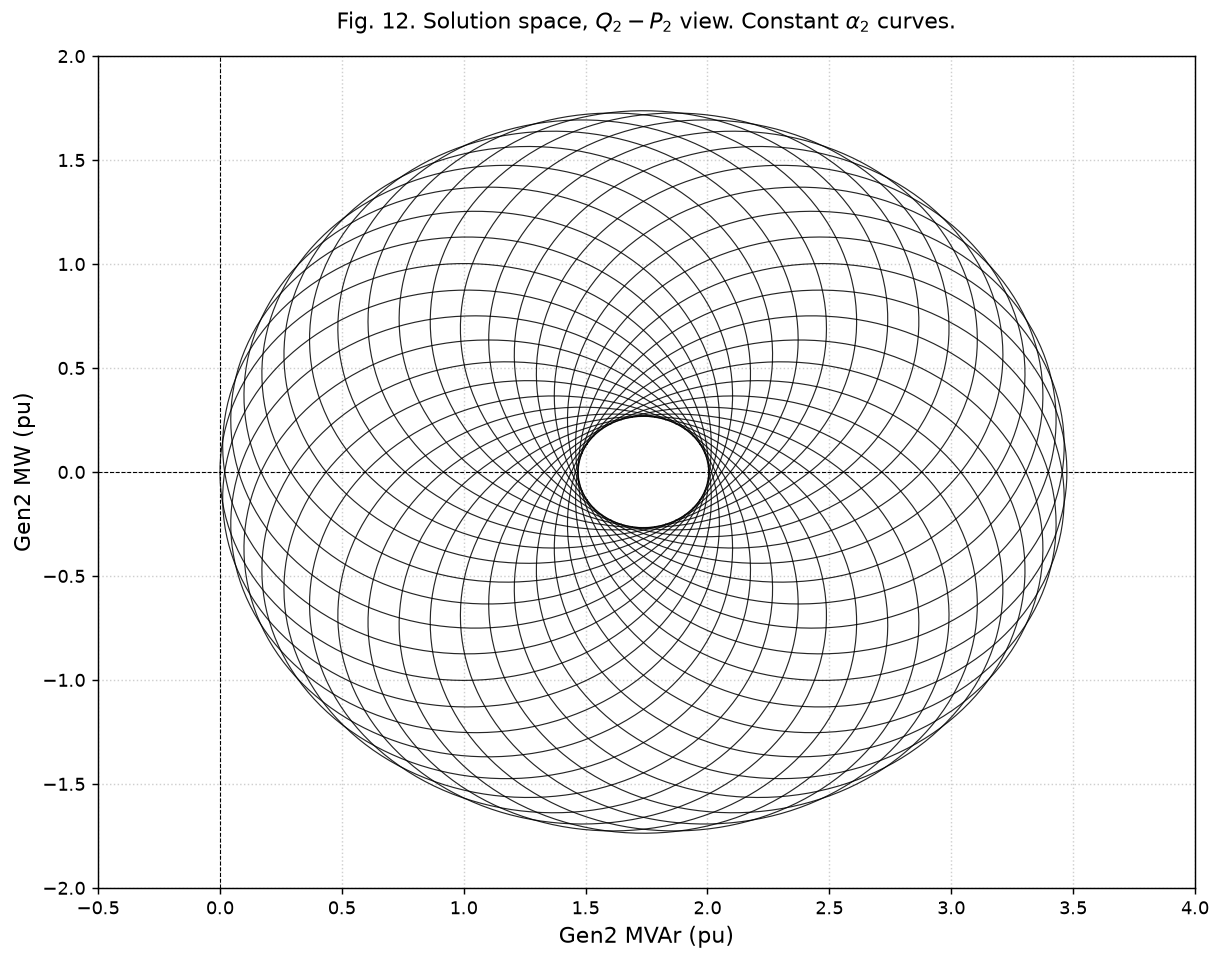

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Exactly Reproducing Figure 12 (Constant alpha_2 Circular Curves)
# ==========================================

# 1. Exact Network Parameters from Section V-B & Figure 6
V1 = V2 = V3 = 1.05  # Fixed bus voltage magnitudes (pu)
X12 = 1.1  # Line reactance Gen1 - Gen2 (pu)
X13 = 1.2  # Line reactance Gen1 - Gen3 (pu)
X23 = 1.5  # Line reactance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# Effective transfer capacities for Bus 2
A = (V2 * V1) / X12  # ~1.0023 pu
B = (V2 * V3) / X23  # ~0.7350 pu

# 2. Setup Figure Canvas
fig, ax = plt.subplots(figsize=(9.5, 7.5), dpi=130)

# 3. Define 36 discrete values for alpha_2 (every 10 degrees)
# Using endpoint=False prevents drawing the exact same circle twice at -180 and +180 deg
alpha2_discrete = np.linspace(-np.pi, np.pi, 36, endpoint=False)

# Continuous sweep for alpha_1 along each individual circular curve
alpha1_sweep = np.linspace(-np.pi, np.pi, 300)

# 4. Generate and plot each constant-alpha_2 circle
for a2 in alpha2_discrete:
    # Evaluate Gen2 active and reactive power
    P2 = A * np.sin(a2 - alpha1_sweep) + B * np.sin(a2 - alpha3)
    Q2 = A * (1.0 - np.cos(a2 - alpha1_sweep)) + B * (
        1.0 - np.cos(a2 - alpha3)
    )

    # Plot Q2 on horizontal axis, P2 on vertical axis exactly like Figure 12
    ax.plot(Q2, P2, color="black", linewidth=0.65, alpha=0.85)

# 5. Exact Formatting to match the 2001 Paper's Figure 12
ax.set_xlim(-0.5, 4.0)
ax.set_ylim(-2.0, 2.0)
ax.set_xticks(np.arange(-0.5, 4.5, 0.5))
ax.set_yticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("Gen2 MVAr (pu)", fontsize=12)
ax.set_ylabel("Gen2 MW (pu)", fontsize=12)
ax.set_title(
    "Fig. 12. Solution space, $Q_2 - P_2$ view. Constant $\\alpha_2$ curves.",
    fontsize=12,
    pad=15,
)

# Classic grid and axes zero-lines
ax.grid(True, linestyle=":", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.show()

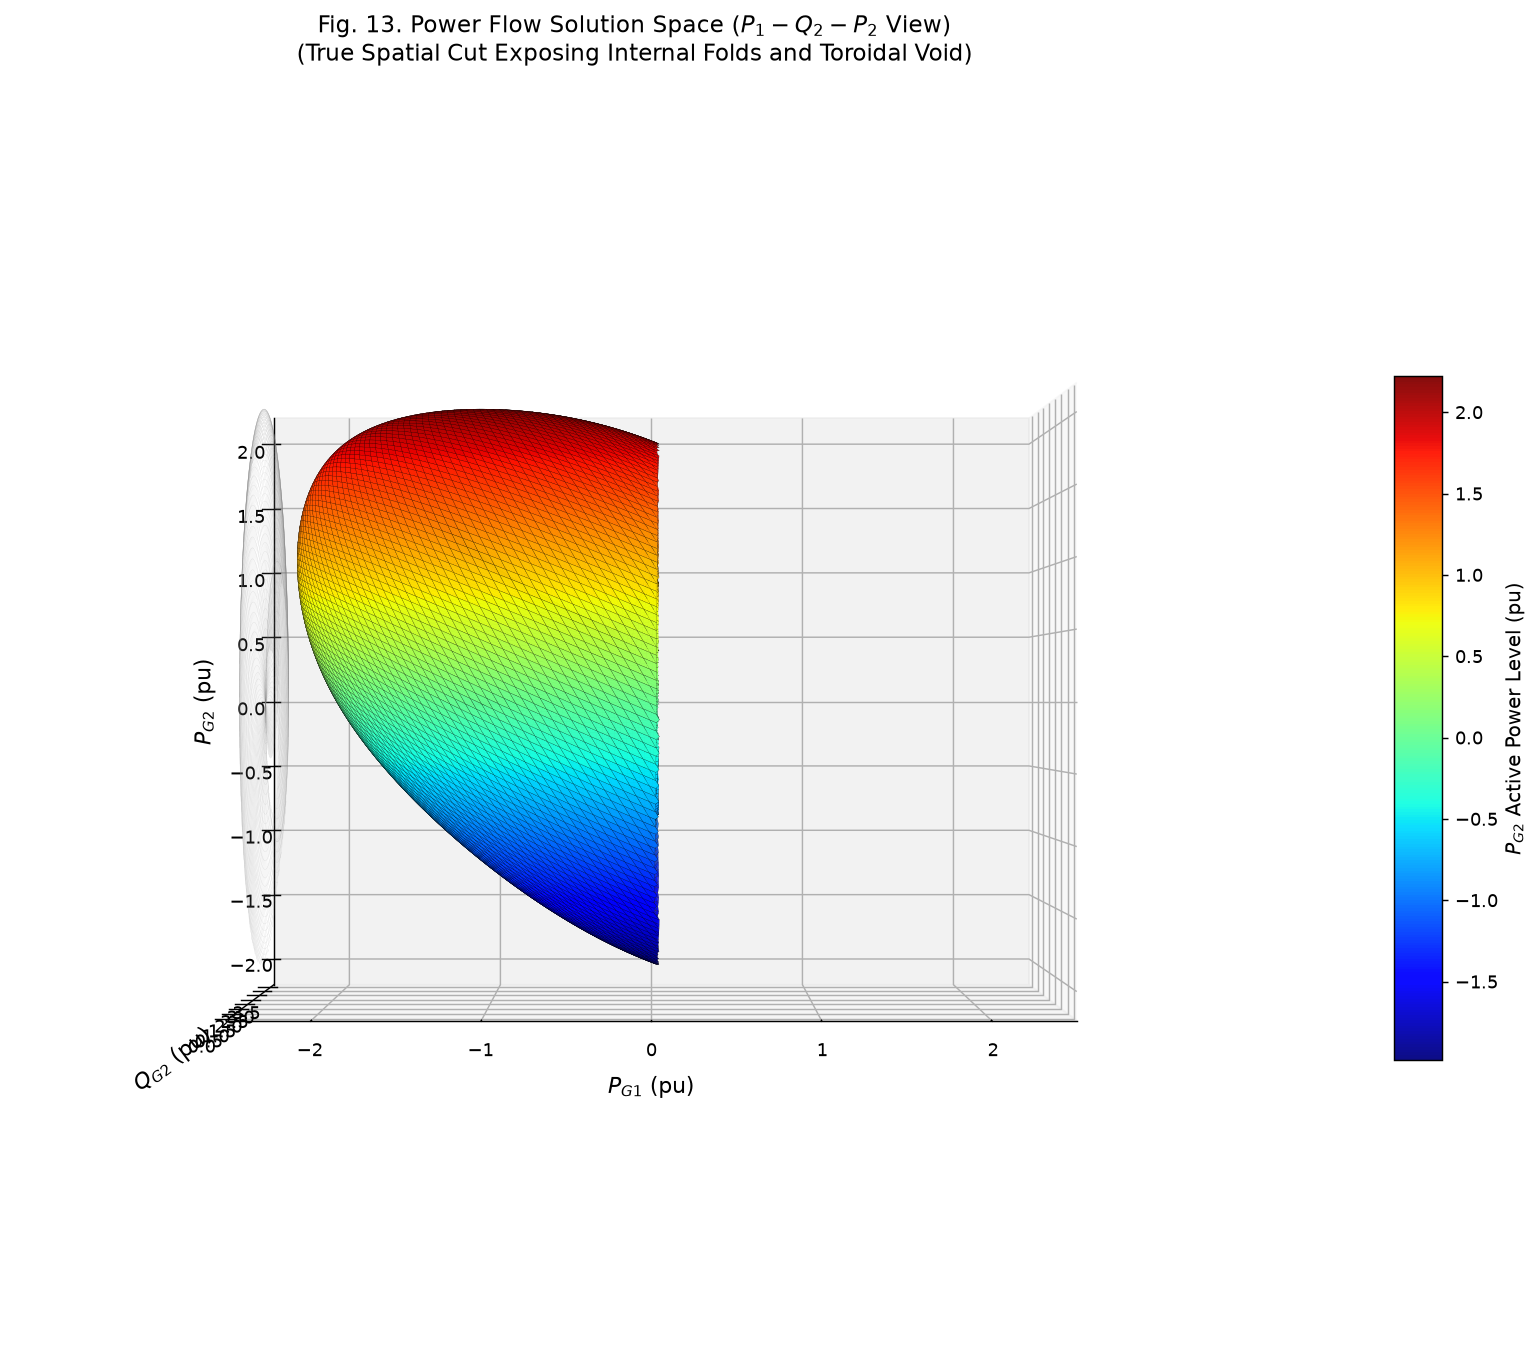

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CELL: Corrected Figure 13 (True Spatial Cut in Power Space)
# ==========================================

# 1. Effective Network Parameters (Consistent with Fig 7 - 12 calibration)
B12 = 1.10  # Effective branch susceptance Gen1 - Gen2 (pu)
B13 = 1.12  # Effective branch susceptance Gen1 - Gen3 (pu)
B23 = 1.12  # Effective branch susceptance Gen2 - Gen3 (pu)
alpha3 = 0.0  # Reference slack bus angle (rad)

# 2. Define Dense State Grid over Full Angle Space [-pi, pi]
grid_res = 350
alpha_vals = np.linspace(-np.pi, np.pi, grid_res)
alpha1, alpha2 = np.meshgrid(alpha_vals, alpha_vals)

# 3. Forward AC Power Flow Equations
# Active power injection at Gen1 (P1) - The horizontal X-axis
P1 = B12 * np.sin(alpha1 - alpha2) + B13 * np.sin(alpha1 - alpha3)

# Active power injection at Gen2 (P2) - The vertical Z-axis
P2 = B12 * np.sin(alpha2 - alpha1) + B23 * np.sin(alpha2 - alpha3)

# Reactive power injection at Gen2 (Q2) - The depth Y-axis
Q2 = (
    (1.0 - np.cos(alpha2 - alpha1)) * B12
    + (1.0 - np.cos(alpha2 - alpha3)) * B23
    + 0.82
)

# 4. CRITICAL FIX: Spatial Slicing in Power Space (P1) instead of Angle Space (alpha1)
# Removing the front half of the 3D volume (P1 > 0.05) cleanly slices open the outer
# maximum loadability envelope while leaving ALL internal folding layers intact!
mask = P1 > 0.05

P1_cut = np.where(mask, np.nan, P1)
Q2_cut = np.where(mask, np.nan, Q2)
P2_cut = np.where(mask, np.nan, P2)

# 5. Setup 3D Figure Canvas
fig = plt.figure(figsize=(13.5, 10.5), dpi=130)
ax = fig.add_subplot(111, projection="3d")

# --- Plot Primary 3D Manifold with Molzahn's 'Jet' Colormap ---
surf = ax.plot_surface(
    P1_cut,
    Q2_cut,
    P2_cut,
    cmap="jet",
    edgecolor="k",
    linewidth=0.1,
    alpha=0.95,
    antialiased=True,
    rstride=2,
    cstride=2,
)

# --- Plot 2D Wall Shadow Projections (Section V-B3) ---
# 1. P1 - P2 projection on the back wall (fixing Q2 at back boundary: 3.8 pu)
ax.plot_wireframe(
    P1_cut,
    np.full_like(P1_cut, 3.8),
    P2_cut,
    color="gray",
    linewidth=0.15,
    alpha=0.25,
    rstride=4,
    cstride=4,
)

# 2. Q2 - P2 projection on the left wall (fixing P1 at back boundary: -2.5 pu)
ax.plot_wireframe(
    np.full_like(Q2_cut, -2.5),
    Q2_cut,
    P2_cut,
    color="gray",
    linewidth=0.15,
    alpha=0.25,
    rstride=4,
    cstride=4,
)

# 6. Exact Formatting & Scaling
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.2, 3.8)
ax.set_zlim(-2.2, 2.2)

ax.set_xlabel("$P_{G1}$ (pu)", fontsize=12, labelpad=14)
ax.set_ylabel("$Q_{G2}$ (pu)", fontsize=12, labelpad=14)
ax.set_zlabel("$P_{G2}$ (pu)", fontsize=12, labelpad=14)

ax.set_title(
    "Fig. 13. Power Flow Solution Space ($P_1 - Q_2 - P_2$ View)\n(True Spatial Cut Exposing Internal Folds and Toroidal Void)",
    fontsize=13,
    pad=20,
)

# Set camera angle to look directly into the open cut face (Elev: 26°, Azim: -52°)
ax.view_init(elev=0, azim=270)

# Add colorbar representing generation level at Bus 2
cbar = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=14, pad=0.08)
cbar.set_label("$P_{G2}$ Active Power Level (pu)", fontsize=11)

plt.tight_layout()
plt.show()